In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTERNACOES_DOENCA_RESP_RJ.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

In [3]:
df_unificado['num_internacoes'].mean()

np.float64(297.4660909856782)

In [4]:
import pandas as pd
import numpy as np

def build_feature_dataframe(df_unificado: pd.DataFrame) -> pd.DataFrame:
    """
    Cria um dataframe de modelagem com:
      - alvo: internacoes_d1 (D+1)
      - lags de num_internacoes de 0 a 6
      - médias móveis de num_internacoes nas janelas 7, 14 e 21 (causais)
      - ano_mes_idx = (ano - ano_min) * 12 + mes
      - idx_sazonal_mes_exp: média expandida por mês-do-ano do target_col diário (num_internacoes/internacoes), com shift(1)
      - features ambientais (rolling mean) conforme a tabela (variável, janela, shift)

    Observações de segurança (anti-leak):
      * O alvo é D+1; todas as features são calculadas no máximo até o dia t.
      * Não usamos 'internacoes_d1' para gerar features.
      * Lags e rollings só usam dados históricos (shift >= 0) e rolling inclui a linha corrente (t), o que é seguro para prever t+1.
    """
    # Cópia e ordenação temporal
    df = df_unificado.copy()
    if "data_dia" not in df.columns:
        raise ValueError("Coluna 'data_dia' é obrigatória.")
    df["data_dia"] = pd.to_datetime(df["data_dia"])
    df = df.sort_values("data_dia").reset_index(drop=True)

    # Alvo
    if "internacoes_d1" not in df.columns:
        raise ValueError("Coluna 'internacoes_d1' não encontrada.")
    df["target"] = pd.to_numeric(df["internacoes_d1"], errors="coerce")

    # Garantir ano/mes para o índice composto
    if "ano" not in df.columns:
        df["ano"] = df["data_dia"].dt.year
    if "mes" not in df.columns:
        df["mes"] = df["data_dia"].dt.month

    # ano_mes_idx
    ano_min = int(df["ano"].min())
    df["ano_mes_idx"] = (df["ano"] - ano_min) * 12 + df["mes"]

    # idx_sazonal_mes_exp (média expandida por mês-do-ano do número diário de internações)
    target_col = next((c for c in ["num_internacoes", "internacoes"] if c in df.columns), None)
    if target_col is not None:
        # média expandida por mês (1..12), usando APENAS valores anteriores ao dia atual
        idx_saz = (
            df.groupby(df["data_dia"].dt.month)[target_col]
              .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
              .reset_index(level=0, drop=True)
        )
        df["idx_sazonal_mes_exp"] = idx_saz
    else:
        df["idx_sazonal_mes_exp"] = np.nan  # não deveria acontecer com sua base

    # Lags de num_internacoes (0..6)
    if "num_internacoes" not in df.columns:
        raise ValueError("Coluna 'num_internacoes' não encontrada para criar lags.")
    for k in range(0, 7):
        df[f"num_internacoes_lag{k}"] = df["num_internacoes"].shift(k)

    # Médias móveis causais (janelas 7, 14, 21) de num_internacoes
    # min_periods = janela para respeitar integralmente a janela (evita meia-janela)
    for w in (7, 10, 14, 21, 30):
        df[f"num_internacoes_mm{w}"] = (
            df["num_internacoes"]
              .rolling(window=w, min_periods=w)
              .mean()
        )

    # Tabela de variáveis ambientais com (janela, shift)
    # Interpretação: aplicar shift primeiro (para usar valores até t - shift), depois média móvel causal de 'janela' dias.
    specs = [
        ("o3",   150, 0),
        ("o3",   150, 3),
        ("o3",   150, 5),
        ("no",    60, 0),
        ("so2",  150, 3),
        ("so2",  150, 7),
        ("nox",   60, 0),
        ("no2",   30, 0),
        ("pm10",  30, 0),
    ]

    env_features = []
    for var, janela, sh in specs:
        if var in df.columns:
            serie_shifted = df[var].shift(sh)
            feat_name = f"{var}_rollmean_w{janela}_s{sh}"
            df[feat_name] = serie_shifted.rolling(window=janela, min_periods=janela).mean()
            env_features.append(feat_name)
        # se não existir a coluna, apenas ignora (não cria a feature)

    # Seleção final de colunas (features + alvo)
    feature_cols = (
        [f"num_internacoes_lag{k}" for k in range(0, 7)] +
        [f"num_internacoes_mm{w}" for w in (7, 14, 21)] +
        ["ano_mes_idx", "idx_sazonal_mes_exp"] +
        env_features
    )

    # Construir df_model e remover linhas com NaN (vindos de lags/janelas)
    df_model = df[["data_dia", "target", "ano"] + feature_cols].dropna().reset_index(drop=True)

    # Sanidade: garantir que nenhuma feature usa informações do futuro do ponto de vista de t -> (t+1)
    # (Como todas as operações foram shift/rolling causais com shift >= 0, isso já é assegurado.)
    return df_model

# Exemplo de uso:
df_model = build_feature_dataframe(df_unificado)
df_model.head()


,data_dia,target,ano,num_internacoes_lag0,num_internacoes_lag1,num_internacoes_lag2,num_internacoes_lag3,num_internacoes_lag4,num_internacoes_lag5,num_internacoes_lag6,...,idx_sazonal_mes_exp,o3_rollmean_w150_s0,o3_rollmean_w150_s3,o3_rollmean_w150_s5,no_rollmean_w60_s0,so2_rollmean_w150_s3,so2_rollmean_w150_s7,nox_rollmean_w60_s0,no2_rollmean_w30_s0,pm10_rollmean_w30_s0
0,2012-06-05,936.0,2012,1105,1066.0,559.0,728.0,871.0,754.0,1170.0,...,806.000000,-0.303779,-0.277255,-0.278637,1.136801,0.414301,0.393459,1.034961,1.059812,0.383235
1,2012-06-06,585.0,2012,936,1105.0,1066.0,559.0,728.0,871.0,754.0,...,865.800000,-0.321085,-0.283468,-0.276787,1.174407,0.416940,0.407921,1.061730,1.081700,0.411494
2,2012-06-07,546.0,2012,585,936.0,1105.0,1066.0,559.0,728.0,871.0,...,877.500000,-0.320893,-0.293875,-0.277255,1.179437,0.428246,0.418430,1.058270,1.043066,0.381050
3,2012-06-08,507.0,2012,546,585.0,936.0,1105.0,1066.0,559.0,728.0,...,835.714286,-0.315112,-0.303779,-0.283468,1.200897,0.433921,0.413985,1.064614,1.022174,0.328295
4,2012-06-09,663.0,2012,507,546.0,585.0,936.0,1105.0,1066.0,559.0,...,799.500000,-0.315064,-0.321085,-0.293875,1.187218,0.429439,0.414301,1.052262,0.987779,0.251517


In [8]:
def create_sequences(data, target, n_steps):
    X_seq, y_seq = [], []

    # Verificação de consistência
    assert len(data) == len(target), "Dados e alvo têm tamanhos diferentes!"

    for i in range(n_steps, len(data)):
        X_seq.append(data[i - n_steps:i])      # janela de n_steps
        y_seq.append(target[i])                # alvo futuro (no tempo i)

    return np.array(X_seq), np.array(y_seq)

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)
    }

In [9]:
def criar_modelo_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [10]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np

def treinar_lstm_model(df, target, n_steps=30, n_splits=5):
    print(f"Treinando modelo LSTM para {target}")

    features = [col for col in df.columns if col not in ['data_dia', 'classificacao',
        'num_internacoes', 'internacoes_d1', 'internacoes_d7', target]]

    X = df[features].values
    y = df[target].values
    y_log = np.log1p(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq))[-1]

    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]

    test_idx = np.arange(len(y_seq))[test_index]

    model = criar_modelo_lstm((n_steps, X_train.shape[2]))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=5)
        ],
        verbose=1
    )

    return model, history, X_test, y_test, test_idx, y_seq, df

In [11]:
def avaliar_lstm(model, history, X_test, y_test, test_idx, y_seq, df, n_steps=14, max_points=150):
    y_pred = np.expm1(model.predict(X_test).flatten())
    y_true = np.expm1(y_test)
    dates = df.iloc[test_idx + n_steps]['data_dia'].values
    resultados = calcular_metricas(y_true, y_pred)

    print(f"\n Chart 1: Last {max_points} points (sequential index)")
    idx_ini = max(0, len(y_true) - max_points)
    x = np.arange(len(y_true))[idx_ini:]
    y_true_plot = y_true[idx_ini:]
    y_pred_plot = y_pred[idx_ini:]

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true_plot, label="Actual", marker='o')
    plt.plot(x, y_pred_plot, label="LSTM", linestyle='--', marker='s')
    plt.fill_between(x, y_true_plot, y_pred_plot, color='gray', alpha=0.2)
    plt.title(f"LSTM Predictions vs Actual Values (last {max_points})")
    plt.xlabel("Index")
    plt.ylabel("Hospitalizations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(" Chart 3: Loss curves")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("LSTM Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nLSTM Metrics:")
    for metric, value in resultados.items():
        unit = "%" if "MAPE" in metric else ""
        print(f" - {metric:<10}: {value:.2f}{unit}")

    return resultados


In [14]:
df_model.dropna(inplace=True)

model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq = treinar_lstm_model(df_model, 'target')

Treinando modelo LSTM para target
Epoch 1/100


c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.7616 - val_loss: 0.5562 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1288 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1033 - val_loss: 0.4598 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0988 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0887 - val_loss: 0.3415 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0844 - val_loss: 0.3943 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0825 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0807 - val_loss: 0.3299 - learning_rate: 0.0010
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0825 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 10/100
94/94 ━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

 Chart 1: Last 150 points (sequential index)


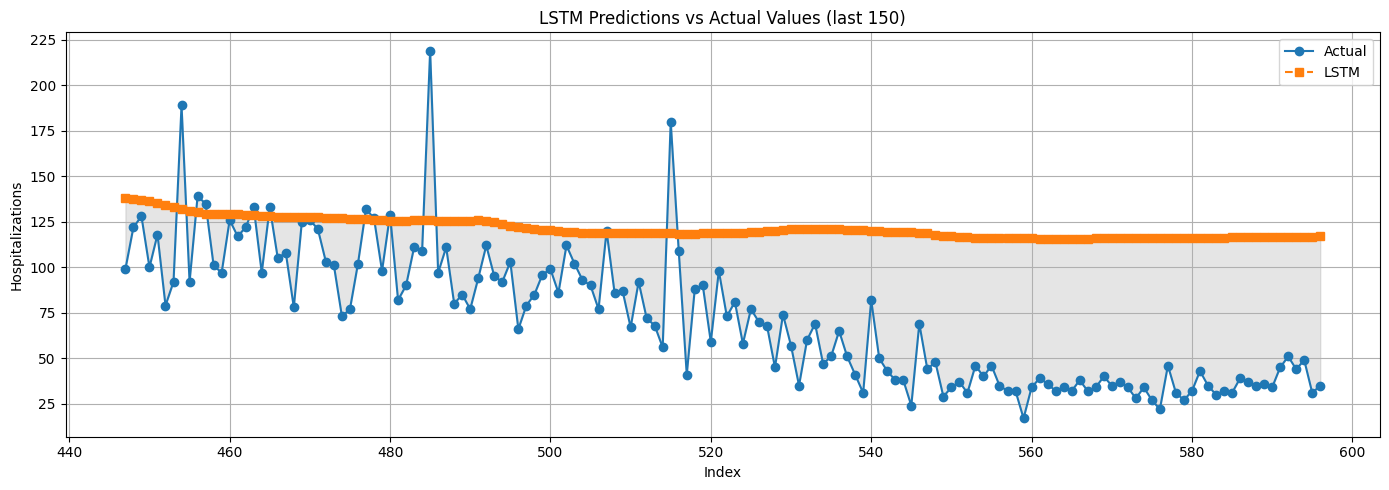

 Chart 3: Loss curves


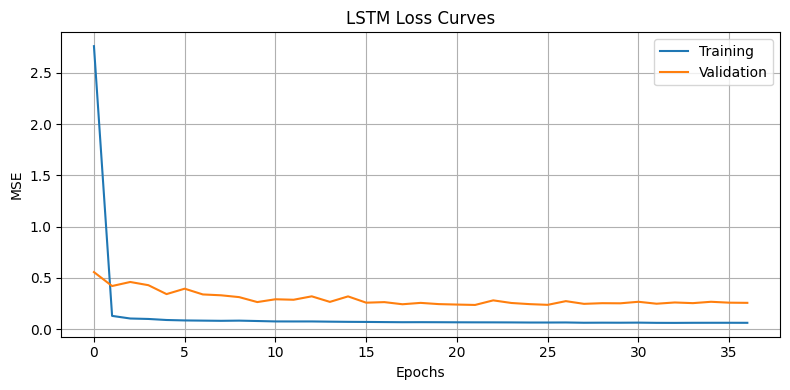


LSTM Metrics:
 - RMSE      : 52.78
 - MAE       : 43.17
 - MAPE (%)  : 50.22%


{'RMSE': np.float64(52.78), 'MAE': 43.17, 'MAPE (%)': 50.22}

In [15]:
avaliar_lstm(model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq)


Formato do dataframe de modelagem: (3613, 24)
Período dos dados: de 2012-06-05 a 2024-02-19
--------------------------------------------------
Iniciando avaliação do modelo: GradientBoostingRegressor
  - Fold 1/5
  - Fold 2/5
  - Fold 3/5
  - Fold 4/5
  - Fold 5/5

Resultados da Validação Cruzada:
  - RMSE médio: 101.0555
  - MAE médio: 78.1222
  - MAPE médio: 51.8795%
  - R2 médio: -0.4748


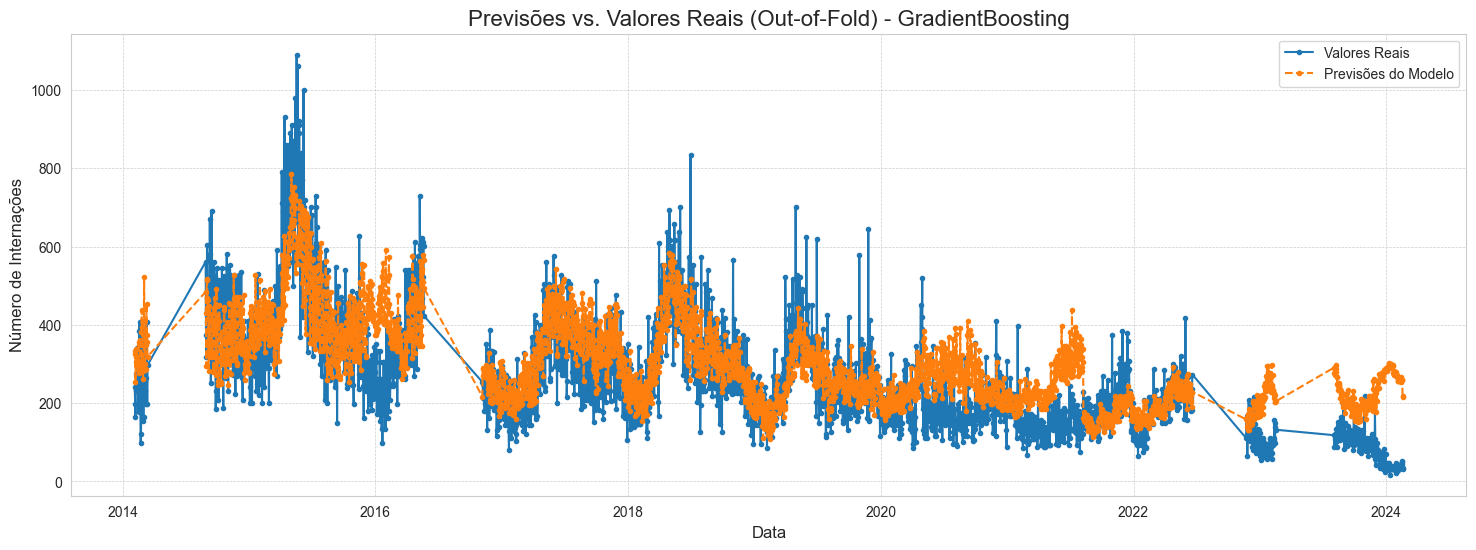

--------------------------------------------------
Iniciando avaliação do modelo: XGBRegressor
  - Fold 1/5
  - Fold 2/5
  - Fold 3/5
  - Fold 4/5
  - Fold 5/5

Resultados da Validação Cruzada:
  - RMSE médio: 101.2110
  - MAE médio: 81.7145
  - MAPE médio: 49.4568%
  - R2 médio: -0.4893


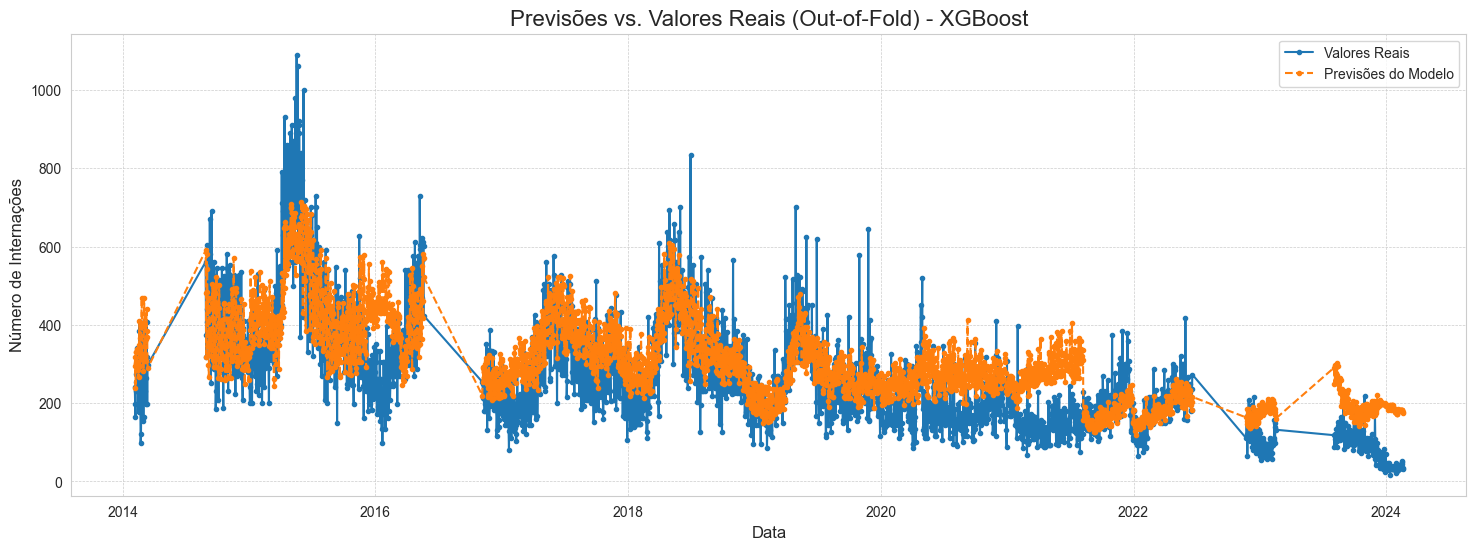


Resumo Comparativo das Métricas
                        RMSE        MAE       MAPE        R2
GradientBoosting  101.055514  78.122236  51.879474 -0.474787
XGBoost           101.211021  81.714482  49.456768 -0.489265


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb # Você pode precisar instalar: pip install xgboost

# Definindo um estilo para os gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)

# --- PASSO 1: DADOS E ENGENHARIA DE FEATURES ---
# Para tornar o código executável, vamos criar um dataframe 'df_unificado' de exemplo.
# No seu caso, você usará o seu dataframe real.
def create_dummy_data():
    """Cria um dataframe de exemplo para demonstração."""
    datas = pd.to_datetime(pd.date_range(start='2018-01-01', end='2023-12-31', freq='D'))
    n = len(datas)
    # Série com sazonalidade (picos no meio do ano) e tendência
    sazonalidade = 15 * np.sin(2 * np.pi * (datas.dayofyear - 150) / 365.25)
    tendencia = np.linspace(50, 80, n)
    ruido = np.random.normal(0, 8, n)
    internacoes = np.maximum(0, tendencia + sazonalidade + ruido).astype(int)

    df = pd.DataFrame({'data_dia': datas, 'num_internacoes': internacoes})
    df['internacoes_d1'] = df['num_internacoes'].shift(-1) # Alvo (D+1)

    # Features ambientais de exemplo
    df['o3'] = 50 + 10 * np.sin(2 * np.pi * datas.dayofyear / 365.25) + np.random.normal(0, 5, n)
    df['no'] = 30 - 15 * np.sin(2 * np.pi * datas.dayofyear / 365.25) + np.random.normal(0, 3, n)
    df['so2'] = 10 + np.random.rand(n) * 5
    df['nox'] = df['no'] + np.random.rand(n) * 2
    df['no2'] = df['nox'] - df['no']
    df['pm10'] = 40 + 20 * np.cos(2 * np.pi * datas.dayofyear / 365.25) + np.random.normal(0, 10, n)

    return df.dropna()

# Sua função de construção de features (incluída como fornecida)
def build_feature_dataframe(df_unificado: pd.DataFrame) -> pd.DataFrame:
    """
    Cria um dataframe de modelagem com:
      - alvo: internacoes_d1 (D+1)
      - lags de num_internacoes de 0 a 6
      - médias móveis de num_internacoes nas janelas 7, 14 e 21 (causais)
      - ano_mes_idx = (ano - ano_min) * 12 + mes
      - idx_sazonal_mes_exp: média expandida por mês-do-ano do target_col diário (num_internacoes/internacoes), com shift(1)
      - features ambientais (rolling mean) conforme a tabela (variável, janela, shift)
    """
    df = df_unificado.copy()
    if "data_dia" not in df.columns:
        raise ValueError("Coluna 'data_dia' é obrigatória.")
    df["data_dia"] = pd.to_datetime(df["data_dia"])
    df = df.sort_values("data_dia").reset_index(drop=True)

    if "internacoes_d1" not in df.columns:
        raise ValueError("Coluna 'internacoes_d1' não encontrada.")
    df["target"] = pd.to_numeric(df["internacoes_d1"], errors="coerce")

    if "ano" not in df.columns:
        df["ano"] = df["data_dia"].dt.year
    if "mes" not in df.columns:
        df["mes"] = df["data_dia"].dt.month

    ano_min = int(df["ano"].min())
    df["ano_mes_idx"] = (df["ano"] - ano_min) * 12 + df["mes"]

    target_col = next((c for c in ["num_internacoes", "internacoes"] if c in df.columns), None)
    if target_col is not None:
        idx_saz = (
            df.groupby(df["data_dia"].dt.month)[target_col]
              .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
              .reset_index(level=0, drop=True)
        )
        df["idx_sazonal_mes_exp"] = idx_saz
    else:
        df["idx_sazonal_mes_exp"] = np.nan

    if "num_internacoes" not in df.columns:
        raise ValueError("Coluna 'num_internacoes' não encontrada para criar lags.")
    for k in range(0, 7):
        df[f"num_internacoes_lag{k}"] = df["num_internacoes"].shift(k)

    # CORREÇÃO: Sua função original usava (7,14,21) para mm e (7,10,14,21,30) para loop. Unificando.
    mm_windows = (7, 14, 21, 30)
    for w in mm_windows:
        df[f"num_internacoes_mm{w}"] = (
            df["num_internacoes"]
              .rolling(window=w, min_periods=w)
              .mean()
        )

    specs = [
        ("o3", 150, 0), ("o3", 150, 3), ("o3", 150, 5),
        ("no", 60, 0),
        ("so2", 150, 3), ("so2", 150, 7),
        ("nox", 60, 0),
        ("no2", 30, 0),
        ("pm10", 30, 0),
    ]

    env_features = []
    for var, janela, sh in specs:
        if var in df.columns:
            serie_shifted = df[var].shift(sh)
            feat_name = f"{var}_rollmean_w{janela}_s{sh}"
            df[feat_name] = serie_shifted.rolling(window=janela, min_periods=janela).mean()
            env_features.append(feat_name)

    feature_cols = (
        [f"num_internacoes_lag{k}" for k in range(0, 7)] +
        [f"num_internacoes_mm{w}" for w in mm_windows] +
        ["ano_mes_idx", "idx_sazonal_mes_exp"] +
        env_features
    )

    df_model = df[["data_dia", "target"] + feature_cols].dropna().reset_index(drop=True)

    return df_model

# --- PASSO 2: FUNÇÕES DE AVALIAÇÃO E TREINAMENTO ---

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calcula um conjunto de métricas de regressão.

    Args:
        y_true (np.ndarray): Valores verdadeiros.
        y_pred (np.ndarray): Valores previstos.

    Returns:
        dict: Dicionário contendo RMSE, MAE, MAPE e R².
    """
    # Garantir que não haja zeros em y_true para o cálculo do MAPE
    mask = y_true != 0
    y_true_safe = y_true[mask]
    y_pred_safe = y_pred[mask]
    
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': mean_absolute_percentage_error(y_true_safe, y_pred_safe) * 100 if len(y_true_safe) > 0 else np.inf,
        'R2': r2_score(y_true, y_pred)
    }
    return metrics

def train_and_evaluate_model(df: pd.DataFrame, model, feature_cols: list, target_col: str, n_splits: int = 5):
    """
    Treina e avalia um modelo usando TimeSeriesSplit com transformação log1p do alvo.

    Args:
        df (pd.DataFrame): O dataframe de modelagem.
        model: O modelo de machine learning a ser treinado (ex: XGBRegressor()).
        feature_cols (list): Lista de nomes das colunas de features.
        target_col (str): O nome da coluna alvo.
        n_splits (int): O número de divisões para o TimeSeriesSplit.

    Returns:
        tuple: Contendo um dicionário de métricas médias e um dataframe com previsões fora da amostra.
    """
    X = df[feature_cols]
    y = df[target_col]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    metrics_list = []
    oof_predictions = pd.DataFrame() # Out-of-fold predictions

    print(f"Iniciando avaliação do modelo: {model.__class__.__name__}")
    
    for fold, (train_index, val_index) in enumerate(tscv.split(X)):
        print(f"  - Fold {fold+1}/{n_splits}")
        
        # Divisão dos dados
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Transformação do alvo para o treino
        y_train_log = np.log1p(y_train)

        # Treinamento do modelo
        model.fit(X_train, y_train_log)

        # Previsão
        y_pred_log = model.predict(X_val)

        # Transformação inversa para a escala original
        y_pred = np.expm1(y_pred_log)
        # Garantir que as previsões sejam não-negativas
        y_pred[y_pred < 0] = 0

        # Cálculo das métricas
        fold_metrics = calculate_metrics(y_val, y_pred)
        metrics_list.append(fold_metrics)
        
        # Guardar previsões para análise posterior
        fold_preds = df.iloc[val_index][["data_dia", target_col]].copy()
        fold_preds['prediction'] = y_pred
        oof_predictions = pd.concat([oof_predictions, fold_preds])

    # Agregação dos resultados
    avg_metrics = pd.DataFrame(metrics_list).mean().to_dict()
    
    print("\nResultados da Validação Cruzada:")
    for metric, value in avg_metrics.items():
        unit = "%" if "MAPE" in metric else ""
        print(f"  - {metric} médio: {value:.4f}{unit}")
        
    return avg_metrics, oof_predictions

def plot_predictions(oof_df: pd.DataFrame, model_name: str):
    """
    Plota as previsões versus os valores reais da última janela de validação.

    Args:
        oof_df (pd.DataFrame): Dataframe com as previsões fora da amostra (out-of-fold).
        model_name (str): Nome do modelo para o título do gráfico.
    """
    plt.figure(figsize=(18, 6))
    plt.plot(oof_df['data_dia'], oof_df['target'], label='Valores Reais', marker='.', linestyle='-')
    plt.plot(oof_df['data_dia'], oof_df['prediction'], label='Previsões do Modelo', marker='.', linestyle='--')
    plt.title(f'Previsões vs. Valores Reais (Out-of-Fold) - {model_name}', fontsize=16)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Número de Internações', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# --- PASSO 3: EXECUÇÃO DO PIPELINE ---

if __name__ == '__main__':
    # 1. Carregar e preparar os dados
    df_model = build_feature_dataframe(df_unificado)
    
    print(f"Formato do dataframe de modelagem: {df_model.shape}")
    print(f"Período dos dados: de {df_model['data_dia'].min().date()} a {df_model['data_dia'].max().date()}")

    # 2. Definir features e alvo
    target_column = 'target'
    feature_columns = [col for col in df_model.columns if col not in ['data_dia', target_column]]

    # 3. Configurar os modelos para testar
    # Parâmetros escolhidos para serem um bom ponto de partida.
    # `n_estimators` alto é bom quando combinado com `early_stopping_rounds` (no XGBoost)
    # ou pode ser ajustado para o GradientBoosting.
    models_to_test = {
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=42
        ),
        "XGBoost": xgb.XGBRegressor(
            objective='reg:squarederror',
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    }

    results = {}
    
    # 4. Iterar, treinar e avaliar cada modelo
    for model_name, model_instance in models_to_test.items():
        print("-" * 50)
        avg_metrics, oof_preds = train_and_evaluate_model(
            df=df_model,
            model=model_instance,
            feature_cols=feature_columns,
            target_col=target_column,
            n_splits=5 # 5 folds é um bom número para começar
        )
        results[model_name] = avg_metrics
        plot_predictions(oof_preds, model_name)
    
    # 5. Apresentar um resumo comparativo
    print("\n" + "="*50)
    print("Resumo Comparativo das Métricas")
    print("="*50)
    results_df = pd.DataFrame(results).T
    print(results_df)